In [1]:
import pandas as pd
import numpy as np
import ast

In [51]:
# df = pd.read_csv("streamer_tags.csv")

# # convert the `tags` column from string to dictionary
# df["tags"] = df["tags"].apply(ast.literal_eval)

# KEYS = list(df["tags"].apply(lambda x: set(x.keys())).iloc[0])
# print(f"Keys: {KEYS}")

In [52]:
df = pd.read_csv("/nas02/home/kevin/recsys_pipeline/data/raw/streamers.csv")

# only keep `pfid` and `tags`
df = df[["pfid", "tags"]]

# convert the `tags` column from string to dictionary
df["tags"] = df["tags"].apply(ast.literal_eval)

# check streamers are unique
assert df["pfid"].nunique() == len(df)

# assert that all tags have the same keys
keys = df["tags"].apply(lambda x: set(x.keys()))
assert all(keys == keys.iloc[0])

print(f"Number of streamers: {len(df)}")

KEYS = list(df["tags"].apply(lambda x: set(x.keys())).iloc[0])
print(f"Keys: {KEYS}")

Number of streamers: 1685
Keys: ['appearance', 'personality', 'featured_topics', 'talents', 'live_streaming_style', 'gender']


# Preprocessing

In [53]:
gender_map = {
    '女': '女',
    '女性': '女',
    '女生': '女',
    'woman': '女',
    'female': '女',
    '男': '男',
    '男性': '男',
    '男生': '男',
    'man': '男',
    'male': '男'
}

def normalize_tags(tags: dict) -> dict:
    tags = tags.copy()
    if "gender" in tags:
        raw_gender = tags["gender"].strip().lower()
        if raw_gender not in gender_map:
            print(f"Unknow raw gender: {raw_gender}")
        tags["gender"] = gender_map.get(raw_gender, raw_gender) # fallback to original if not mapped
    return tags

df["tags"] = df["tags"].apply(normalize_tags)

In [54]:
def flatten_tags(tags: dict) -> str:
    """
    Convert key-value pairs into a flat sequence like: "key value key value ..."
    """
    return " ".join(f"{key} {value}" for key, value in tags.items())

# apply the flatten_tags function to the 'tags' column
df["item_sentence"] = df["tags"].apply(flatten_tags)

# Apply Embeddings

## Pre-trained MiniLM-L12-v2

In [30]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

# Generate embeddings for each item sentence
embeddings = model.encode(df['item_sentence'].tolist(), show_progress_bar=True)


Batches: 100%|██████████| 53/53 [00:00<00:00, 57.17it/s]


In [31]:
print("NaN in embeddings:", np.isnan(embeddings).any())
print("Inf in embeddings:", np.isinf(embeddings).any())
print("Number of samples:", embeddings.shape[0])
print("Embedding dimension:", embeddings.shape[1])

NaN in embeddings: False
Inf in embeddings: False
Number of samples: 1685
Embedding dimension: 384


# Fine-tuned Sentence Transformer

In [55]:
from sentence_transformers import SentenceTransformer

model_path = "/nas02/home/kevin/recsys_pipeline/src/embeddings/models/epoch40/best_model"
model = SentenceTransformer(model_path)

# Generate embeddings for each item sentence
embeddings = model.encode(df['item_sentence'].tolist(), show_progress_bar=True)


Batches: 100%|██████████| 53/53 [00:00<00:00, 58.45it/s]


In [56]:
print("NaN in embeddings:", np.isnan(embeddings).any())
print("Inf in embeddings:", np.isinf(embeddings).any())
print("Number of samples:", embeddings.shape[0])
print("Embedding dimension:", embeddings.shape[1])

NaN in embeddings: False
Inf in embeddings: False
Number of samples: 1685
Embedding dimension: 384


# Extract tags into Separate Columns

In [57]:
tags_df = df["tags"].apply(pd.Series)
df = df.drop(columns=['tags']).join(tags_df)

In [58]:
df.columns

Index(['pfid', 'item_sentence', 'gender', 'personality', 'appearance',
       'talents', 'featured_topics', 'live_streaming_style'],
      dtype='object')

## Tag Analysis

In [10]:
tags_df["appearance"].unique()

array(['嬰兒臉、豐滿、長髮', '嬰兒臉、長髮、豐滿', '長髮、鄰家、甜美', '鄰家', '長髮、甜美、可愛', '甜美、長髮、鄰家',
       '性感、長髮、鄰家', '鄰家、短髮', '長髮、甜美、鄰家', '鄰家、韓系', '鄰家、長髮', '長髮、嬰兒臉',
       '韓系、短髮', '鄰家、長髮、豐滿', '短髮、眼鏡', '長髮、性感、豐滿', '長髮、可愛、甜美', '短髮、鄰家、性感',
       '鄰家、長髮、甜美', '長髮、性感、鄰家', '嬰兒臉、長髮、鄰家', '甜美、長髮、性感', '長髮', '豐滿、鄰家、長髮',
       '甜美、性感、豐滿', '短髮、韓系', '混血、性感、長髮', '性感、長髮、豐滿', '長髮、性感、可愛',
       '鄰家、豐滿、長髮', '豐滿、長髮、鄰家', '長髮、可愛、性感', '韓系、鄰家', '短髮、鄰家、可愛',
       '鄰家、短髮、韓系', '長髮、鄰家', '鄰家、長髮、性感', '短髮、鄰家', '長髮、鄰家、性感', '鄰家、長髮、嬰兒臉',
       '鄰家、長髮、可愛', '鄰家、長髮、韓系', '長髮、日系、鄰家', '嬰兒臉、長髮、性感', '嬰兒臉、短髮、鄰家',
       '甜美、長髮、可愛', '性感、長髮', '嬰兒臉、長髮、可愛', '鄰家、長髮、清純', '長髮、鄰家、可愛',
       '甜美、可愛、長髮', '甜美、長髮、韓系', '嬰兒臉、鄰家、長髮', '長髮、豐滿', '甜美、性感、長髮',
       '短髮、鄰家、甜美', '短髮', '性感、豐滿、長髮', '長髮、豐滿、鄰家', '性感、豐滿、仙氣空靈',
       '長髮、鄰家、仙氣空靈', '嬰兒臉、長髮、甜美', '性感、長髮、甜美', '可愛、長髮、日系', '短髮、可愛、性感',
       '甜美、短髮、韓系', '長髮、鄰家、嬰兒臉', '長髮、鄰家、豐滿', '長髮、鄰家、清秀', '韓系', '圓臉、短髮',
       '鄰家、短髮、甜美', '甜美、可愛、豐滿', '韓系、少年感、高瘦', '嬰兒臉、性感、長髮', '長髮、甜美、氣質',
       '圓臉、短髮、眼鏡', '嬰兒臉、短髮、日系', '嬰兒臉

In [11]:
tags_df["talents"].unique()

array(['唱歌', '吉他彈唱', '唱歌、鋼琴', '唱歌、彈吉他、彈鋼琴', '唱歌、化妝', '大提琴演奏、唱歌', '鋼琴彈唱',
       '唱歌、化妝、縫紉', '唱歌、玩遊戲', '唱歌、吹奏樂器', '唱歌、彈鋼琴', '唱歌、聊天、變裝', '化妝、整理衣物',
       '唱歌、化妝、聊天', '唱歌、與觀眾互動', '唱歌、彈琴', '唱歌、彈吉他', '唱歌、跳舞', '唱歌、聊天',
       '小提琴演奏', '唱歌、跳舞、搞笑', '唱歌、吃播', '舞蹈', '唱歌、吉他彈唱', '唱歌、聊天、吃播',
       '唱歌、演奏樂器', '鋼琴演奏', '化妝、唱歌', '唱歌、與寵物互動', '唱歌、組裝樂高、拆盲盒',
       '塔羅占卜、唱歌、化妝、吃播', '舞蹈、互動', '吉他彈唱、清唱', '唱歌、吃東西', '吃播、換裝、聊天',
       '二胡演奏、唱歌', '唱歌、彈奏樂器', '展示手工藝品', '揚琴演奏、唱歌', '跳舞、化妝', '唱歌、聊天、化妝',
       '舞蹈、唱歌', '唱歌、繪畫', '唱歌、彈古箏', '唱歌、彈奏古箏、彈奏鋼琴、包粽子', '唱歌、聊天、組裝樂高',
       '彈奏琵琶、唱歌', '聊天', '唱歌、模仿、搞笑', '化妝、唱歌、聊天', '唱歌、跳舞、換裝', '唱歌、吉他',
       '唱歌、聊天、化妝、手工藝', '唱歌、塔羅牌占卜、魔術', '唱歌、玩骰子', '唱歌、跳舞、聊天', '唱歌、跳舞、化妝',
       '唱歌、聊天、開箱', '彈奏烏克麗麗、唱歌', '唱歌、跳舞、模仿', '唱歌、換裝', '無', '唱歌、化妝、吃播',
       '遊戲互動、舞蹈', '唱歌、吉他、化妝', '占星、養鳥', '唱歌、跳舞、玩遊戲', '鋼琴彈奏、唱歌', '琵琶演奏、唱歌',
       '演講', '跳舞、化妝、吃播', '唱歌、彈鋼琴、彈吉他', '唱歌、與貓互動', '唱歌、聊天、分享生活', '烹飪',
       '唱歌、跳舞、繪畫', '唱歌、跳舞、吃播', '舞蹈、唱歌、換裝', '唱歌、跳舞、與寵物互動', '音樂創作、唱歌', '歌唱',
       '唱歌、組裝家具', '繪畫、

In [12]:
tags_df["featured_topics"].unique()

array(['分享生活、與觀眾互動', '聊天、唱歌、分享生活', '棒球、日常生活、美妝', '唱歌、聊天、禮物互動', '唱歌、聊天、互動',
       '音樂分享、生活日常、粉絲互動', '生活分享、情感交流、美妝保養', '音樂、生活分享、粉絲互動', '音樂表演、與觀眾互動',
       '唱歌、化妝、分享生活、與觀眾互動', '音樂分享、生活日常、與觀眾互動', '分享生活、工作經驗、閒聊',
       '閒聊、唱歌、化妝、縫紉', '遊戲、音樂', '閒聊、唱歌、化妝', '生活分享、美食、旅遊、直播互動',
       '音樂表演、生活分享、與觀眾互動', '音樂、生活分享、與觀眾互動', '與觀眾互動、點歌、聊天', '日常生活、遊戲、寵物',
       '化妝、日常生活分享', '日常生活分享、與觀眾互動', '唱歌、化妝、聊天、生活分享', '閒聊、分享生活、與觀眾互動',
       '唱歌、與貓互動', '寵物、生活分享、遊戲', '與觀眾互動、分享生活、唱歌', '音樂、生活分享', '唱歌、聊天、分享生活',
       '與觀眾互動、分享生活趣事、討論直播內容', '美食分享、音樂表演、與觀眾互動', '聊天互動、唱歌、分享生活',
       '音樂表演、生活分享', '生活分享、美食', '唱歌、聊天、搞笑', '日常生活、寵物、直播活動', '閒聊、唱歌、互動',
       '聊天、唱歌、禮物互動', '閒聊、唱歌、粉絲互動', '日常生活分享、與觀眾互動、唱歌', '與觀眾互動、分享生活趣事',
       '唱歌、聊天、與觀眾互動', '閒聊、唱歌、與觀眾互動', '生活分享、寵物、工作', '日常生活分享、美食、工作經驗',
       '生活分享、閒聊', '生活分享、穿搭、飲料', '音樂表演、日常生活分享、與觀眾互動',
       '日常生活分享、與觀眾互動、直播濾鏡展示', '音樂分享', '唱歌、聊天', '音樂分享、日常生活分享、與觀眾互動', '唱歌',
       'PK、唱歌、搞笑', '唱歌、美食', '唱歌、聊天、化妝', '日常生活分享、與觀眾互動、遊戲', '生活分享、音樂交流',
       '日常生活分享、節日慶祝、遊戲互動', '直播互動、生活分享、

In [13]:
tags_df["live_streaming_style"].unique()

array(['親切、活潑、可愛', '溫馨、互動性強、輕鬆愉快', '輕鬆、活潑、親切', '輕鬆、隨性、親和力強',
       '親切互動，氛圍輕鬆愉快，偶爾穿插歌唱表演，展現多樣魅力。', '輕鬆、隨性、真誠',
       '輕鬆愉快的氛圍，主播積極與觀眾互動，展現多樣才藝，並分享個人生活點滴。',
       '輕鬆愉快的音樂分享會，主播親切幽默，善於與觀眾互動，營造出溫馨的氛圍。', '溫馨、輕鬆、互動性強', '輕鬆、活潑、互動性強',
       '輕鬆、隨性', '親切友善，與觀眾互動頻繁，氛圍輕鬆愉快。', '親切活潑、輕鬆愉快、互動性強', '輕鬆愉快、親切互動',
       '輕鬆活潑、幽默風趣、親和力強', '親切友善、活潑開朗、與觀眾互動頻繁',
       '主播的直播風格活潑有趣，充滿了歡樂的氛圍。她善於與觀眾互動，並透過多樣的變裝和濾鏡效果，為直播增添了許多趣味性。背景的玩偶收藏也為直播間營造出溫馨可愛的氛圍。',
       '輕鬆、隨性，帶有生活化的氛圍，主播會與觀眾分享日常活動，並展現其化妝技巧。', '輕鬆活潑、親切幽默', '親切、活潑、互動性高',
       '溫馨、可愛、療癒', '活潑、親切、互動性強', '親切活潑，與觀眾互動頻繁，氛圍輕鬆愉快。', '親切友善、輕鬆愉快',
       '輕鬆、隨性、與觀眾互動', '親切、活潑、互動性強', '輕鬆活潑、親切友善、幽默風趣', '輕鬆活潑、親切互動、音樂分享',
       '輕鬆活潑、親切互動', '溫馨、輕鬆、互動', '輕鬆、活潑、幽默', '活潑開朗，與觀眾互動熱絡，營造輕鬆愉快的氛圍。',
       '輕鬆愉悅，與觀眾互動頻繁，展現多變的造型和活潑的個性。', '活潑、熱情、親切', '溫馨、親切、活潑',
       '親切友善、輕鬆愉快、互動性強', '親切友善，氛圍輕鬆愉快，主播積極與觀眾互動，並展現多樣的造型和才藝。',
       '主播的直播風格輕鬆愉快，以唱歌為主，並積極與觀眾互動，營造出歡樂的氛圍。她會根據觀眾的留言和要求進行歌曲演唱，並在歌曲間隙與觀眾聊天，分享生活點滴，展現出親和力。直播中不時出現特效和濾鏡，增加趣味性。',
       '親切友善，積極與觀眾互動，營造輕鬆愉快的氛圍。', '活潑

# Apply KMeans Cluster

In [59]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(embeddings)

# 組內距離、組外距離

In [60]:
# cluster validatio

from sklearn.metrics import silhouette_score

score = silhouette_score(embeddings, df['cluster'])
print("Silhouette Score:", score)


Silhouette Score: 0.12701514


In [61]:
from sklearn.metrics import pairwise_distances

# Compute average distance to cluster center
intra_dists = []
for i in range(kmeans.n_clusters):
    cluster_points = embeddings[df['cluster'] == i]
    centroid = kmeans.cluster_centers_[i]
    dists = np.linalg.norm(cluster_points - centroid, axis=1)
    intra_dists.append({
        'cluster': i,
        'count': len(dists),
        'avg_intra_dist': np.mean(dists),
        'max_intra_dist': np.max(dists)
    })

intra_df = pd.DataFrame(intra_dists)

In [62]:
intra_df

,cluster,count,avg_intra_dist,max_intra_dist
0,0,447,0.856558,1.534578
1,1,339,0.958139,1.600628
2,2,344,0.798777,1.487381
3,3,203,0.775737,1.494004
4,4,352,0.934099,1.493816


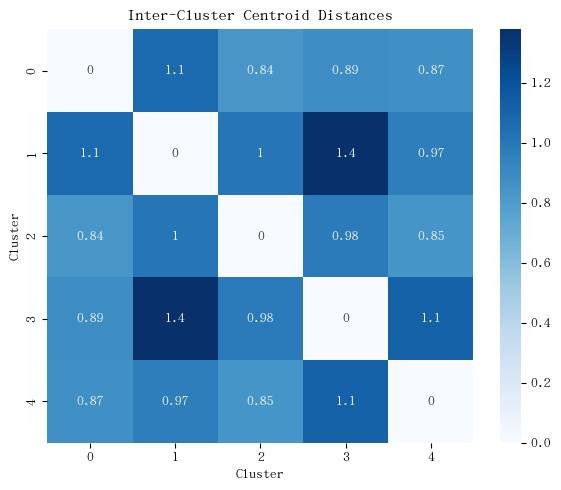

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute pairwise distances between cluster centers
centroid_dists = pairwise_distances(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroid_dists, index=range(kmeans.n_clusters), columns=range(kmeans.n_clusters))

plt.figure(figsize=(6,5))
sns.heatmap(centroid_df, annot=True, cmap='Blues')
plt.title("Inter-Cluster Centroid Distances")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

# Visualize

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.font_manager as fm

for font in fm.fontManager.ttflist:
    if 'TC' in font.name or 'Hei' in font.name or 'Kai' in font.name or 'Song' in font.name:
        print(font.name, font.fname)

AR PL UKai CN /usr/share/fonts/truetype/arphic/ukai.ttc


In [6]:
import matplotlib

matplotlib.font_manager.fontManager.addfont('/usr/share/fonts/truetype/arphic/ukai.ttc')
matplotlib.rc('font', family='AR PL UKai CN')

## t-SNE

In [66]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=min(embeddings.shape[0] // 3, 5))
reduced_tsne = tsne.fit_transform(embeddings)

# add the 2D coordinates to the df
df["tsne_x"] = reduced_tsne[:, 0]
df["tsne_y"] = reduced_tsne[:, 1]

In [67]:
def plot_embedding_scatter(
    df,
    x_col="tsne_x", y_col="tsne_y",
    hue_col="gender",
    title=None,
    legend_title=None,
    save_path=None
):

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=df,
        x=x_col, y=y_col,
        hue=hue_col,
        palette='Set2', s=60, alpha=0.7
    )
    plt.title(title or f'{x_col}-{y_col} Colored by {hue_col}')
    plt.xlabel(x_col.upper())
    plt.ylabel(y_col.upper())
    plt.legend(title=legend_title or hue_col)
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

/tmp/ipykernel_3029489/1697339554.py:22: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AR PL UKai CN.
  plt.tight_layout()
/home/kevin/miniconda3/envs/ml_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AR PL UKai CN.
  fig.canvas.print_figure(bytes_io, **kw)


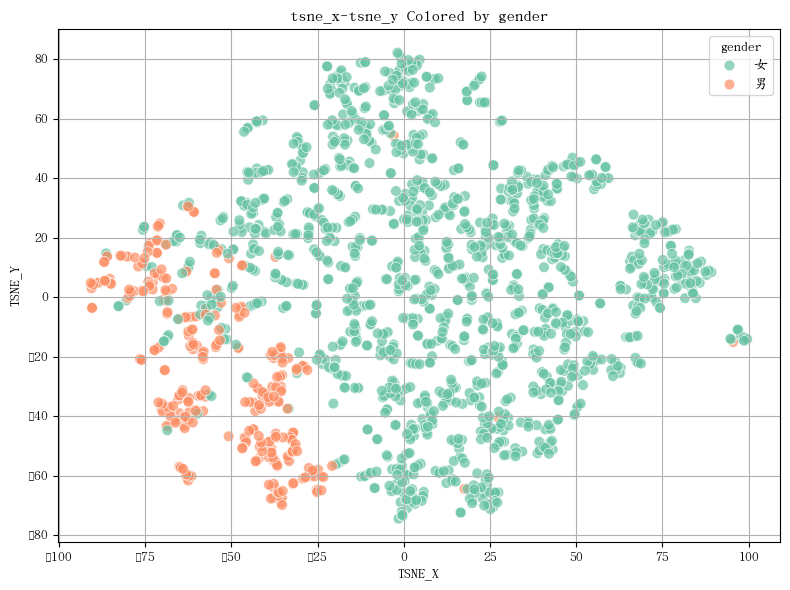

In [68]:
plot_embedding_scatter(df, hue_col="gender")

/tmp/ipykernel_3029489/1697339554.py:22: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AR PL UKai CN.
  plt.tight_layout()
/home/kevin/miniconda3/envs/ml_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AR PL UKai CN.
  fig.canvas.print_figure(bytes_io, **kw)


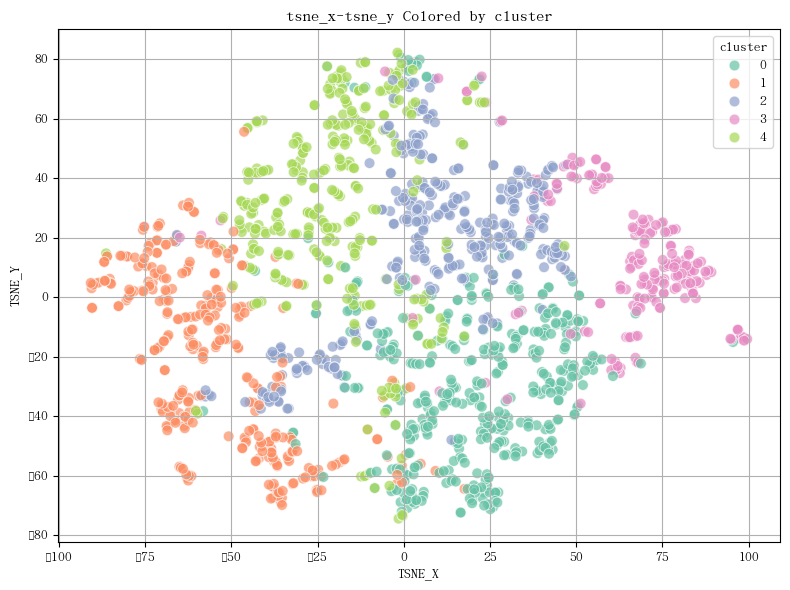

In [69]:
plot_embedding_scatter(df, hue_col="cluster")

/tmp/ipykernel_3029489/1697339554.py:22: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AR PL UKai CN.
  plt.tight_layout()
/home/kevin/miniconda3/envs/ml_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AR PL UKai CN.
  fig.canvas.print_figure(bytes_io, **kw)


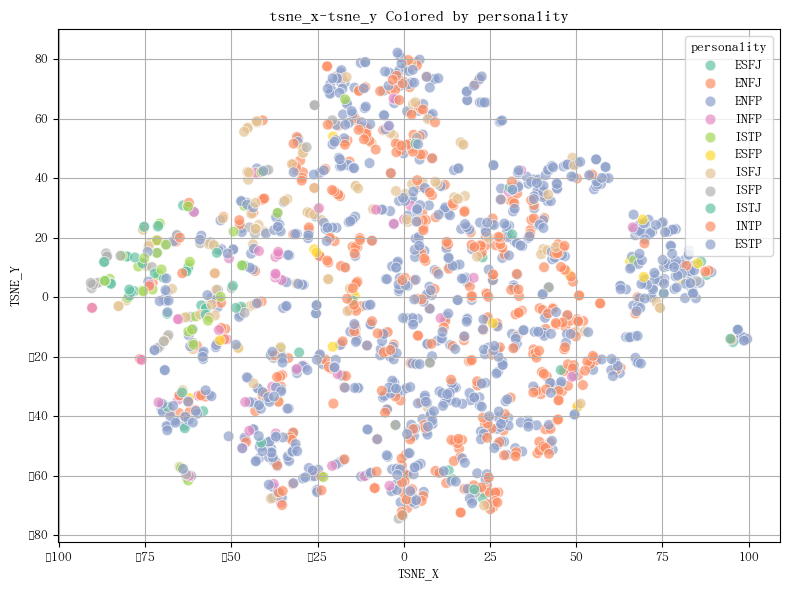

In [70]:
plot_embedding_scatter(df, hue_col="personality")

## UMAP

In [71]:
import umap

umap_model = umap.UMAP(n_components=2, random_state=42)
reduced_umap = umap_model.fit_transform(embeddings)

df['umap_x'] = reduced_umap[:, 0]
df['umap_y'] = reduced_umap[:, 1]

/home/kevin/miniconda3/envs/ml_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


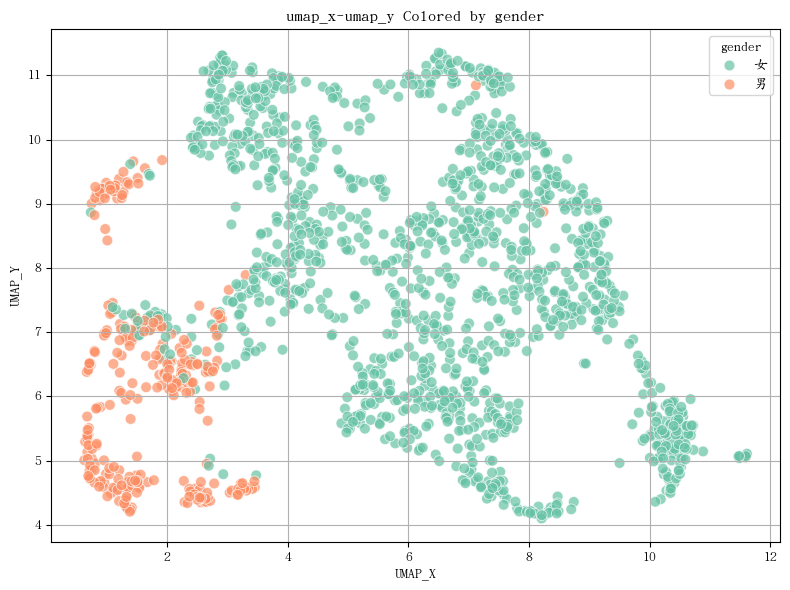

In [72]:
plot_embedding_scatter(
    df=df,
    x_col='umap_x', y_col='umap_y',
    hue_col='gender',
)

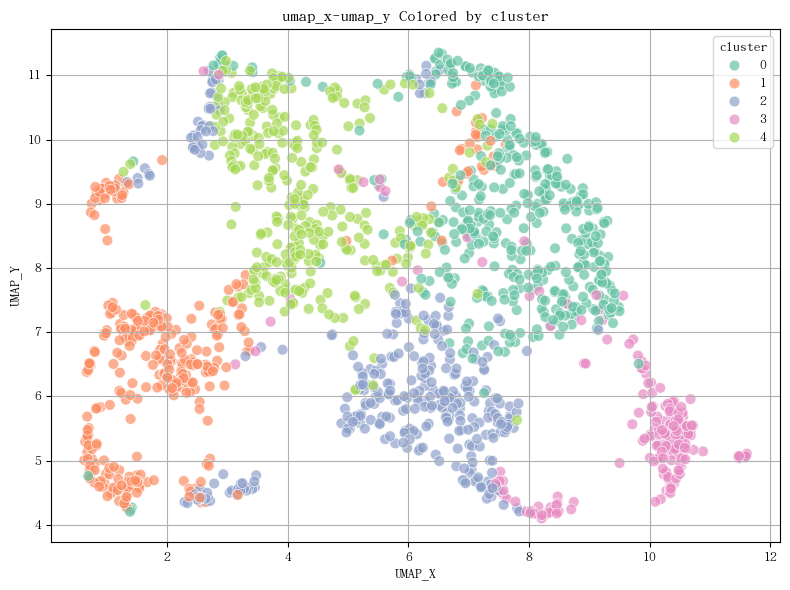

In [73]:
plot_embedding_scatter(
    df=df,
    x_col='umap_x', y_col='umap_y',
    hue_col='cluster',
)

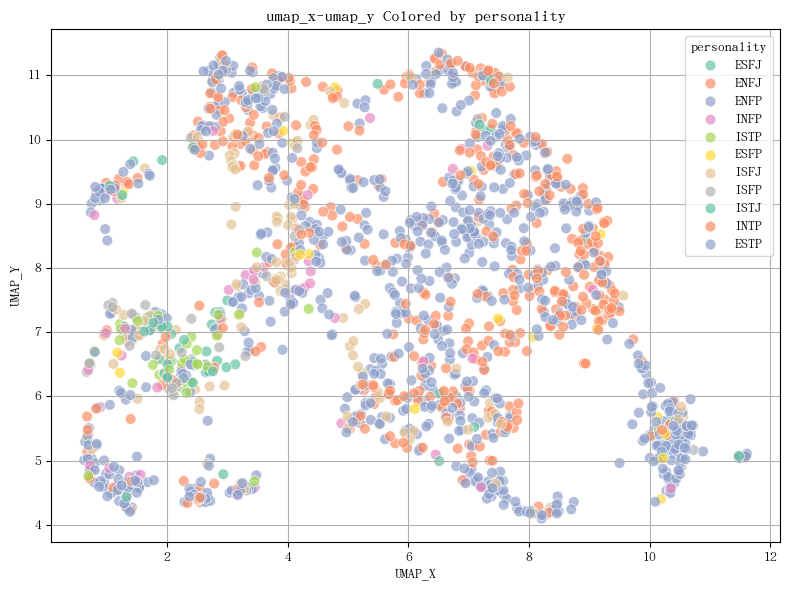

In [74]:
plot_embedding_scatter(
    df=df,
    x_col='umap_x', y_col='umap_y',
    hue_col='personality',
)

# User Embeddings analysis

In [10]:
import pathlib
import pandas as pd
import numpy as np
from typing import Union

def get_emb_paths(dir_path: Union[str, pathlib.Path]) -> tuple[str, str]:
    dir_path = pathlib.Path(dir_path)
    emb_path = next(dir_path.glob("*.npy"))
    lookup_path = next(dir_path.glob("*.parquet"))
    return str(emb_path), str(lookup_path)


def load_embeddings(path: str) -> np.ndarray:
    if path.endswith(".npy"):
        return np.load(path)
    else:
        raise ValueError(f"Unsupported file format for embeddings: {path}")

def load_lookup_table(path: str, id_col: str) -> dict:
    if path.endswith(".parquet"):
        df = pd.read_parquet(path)
    elif path.endswith(".csv"):
        df = pd.read_csv(path)
    else:
        raise ValueError(f"Unsupported file format for lookup table: {path}")
    
    df = df.reset_index(drop=True)

    if id_col not in df.columns:
        raise ValueError(f"Column '{id_col}' not found in the lookup table.")
    if df[id_col].isnull().any():
        raise ValueError(f"Column '{id_col}' contains null values.")
    if df[id_col].duplicated().any():
        raise ValueError(f"Column '{id_col}' contains duplicate values.")
    
    return dict(zip(df[id_col], df.index))

def load_embedding_and_lookup(emb_dir: str, id_col: str) -> tuple[np.ndarray, dict]:
    emb_path, lookup_path = get_emb_paths(emb_dir)
    emb = load_embeddings(emb_path)
    lookup = load_lookup_table(lookup_path, id_col)
    return emb, lookup

In [47]:
user_emb_dir = "/nas02/home/kevin/recsys_pipeline/embeddings/user/MiniLM_40epoch_ts_heavy"
user_embeddings, user_lookup = load_embedding_and_lookup(user_emb_dir, "user_id")

user_df = pd.DataFrame(user_lookup.keys(), columns=["user_id"])

print("User embeddings shape:", user_embeddings.shape)
print("User lookup size:", len(user_lookup))

User embeddings shape: (6861, 384)
User lookup size: 6861


## Apply KMeans Cluster

In [48]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
user_df['cluster'] = kmeans.fit_predict(user_embeddings)


In [49]:
from sklearn.metrics import pairwise_distances

# Compute average distance to cluster center
intra_dists = []
for i in range(kmeans.n_clusters):
    cluster_points = user_embeddings[user_df['cluster'] == i]
    centroid = kmeans.cluster_centers_[i]
    dists = np.linalg.norm(cluster_points - centroid, axis=1)
    intra_dists.append({
        'cluster': i,
        'count': len(dists),
        'avg_intra_dist': np.mean(dists),
        'max_intra_dist': np.max(dists)
    })

intra_df = pd.DataFrame(intra_dists)

In [50]:
intra_df

,cluster,count,avg_intra_dist,max_intra_dist
0,0,1970,0.062339,0.129320
1,1,899,0.061932,0.147077
2,2,829,0.074697,0.159537
3,3,1878,0.063551,0.142937
4,4,1285,0.066001,0.135475


## Plot

### t-SNE

In [51]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=min(user_embeddings.shape[0] // 3, 5))
reduced_tsne = tsne.fit_transform(user_embeddings)

user_df["tsne_x"] = reduced_tsne[:, 0]
user_df["tsne_y"] = reduced_tsne[:, 1]

In [52]:
def plot_embedding_scatter(
    df,
    x_col="tsne_x", y_col="tsne_y",
    hue_col="gender",
    title=None,
    legend_title=None,
    save_path=None
):

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=df,
        x=x_col, y=y_col,
        hue=hue_col,
        palette='Set2', s=60, alpha=0.7
    )
    plt.title(title or f'{x_col}-{y_col} Colored by {hue_col}')
    plt.xlabel(x_col.upper())
    plt.ylabel(y_col.upper())
    plt.legend(title=legend_title or hue_col)
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

/tmp/ipykernel_3898920/1697339554.py:22: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AR PL UKai CN.
  plt.tight_layout()
/home/kevin/miniconda3/envs/ml_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AR PL UKai CN.
  fig.canvas.print_figure(bytes_io, **kw)


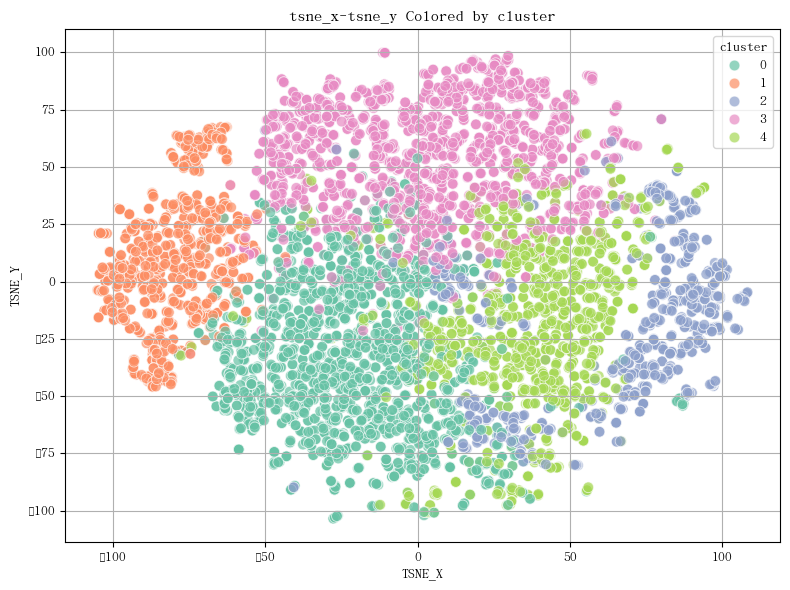

In [53]:
plot_embedding_scatter(user_df, hue_col="cluster")